# Descriptive Statistics — Foundations for Machine Learning

## Objective
This notebook explores core statistical concepts required for machine learning, including:

- Measures of central tendency
- Measures of dispersion
- Data visualization techniques
- Probability distributions

## Why this matters
Understanding data distribution and variability is essential before applying any ML model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset

We use a sample dataset to demonstrate statistical concepts.


In [2]:
ages = [46, 37, 49, 45, 39, 49, 25, 32, 34, 39]

## MEASURE OF CENTRAL TENDENCY
These describe the central value of a dataset\
1.Mean:\
2.Mode\
3.Median

In [3]:
import numpy as np

ages = [46, 37, 49, 45, 39, 49, 25, 32, 34, 39]
print(np.mean(ages))
print(np.median(ages))

39.5
39.0



Mean vs Median when it comes to outliers

Mean is sensitive to outliers\n
Median is robust  

In [4]:
ages = [46, 37, 49, 45, 39, 49, 25, 32, 34, 39, 100] #adding 100 as an outlier here

print(np.mean(ages)) # value goes from 39.5 to 45.0
# mean tend to get affected when an outlier shows up and it is not effective for finding out central tendency okay

# but on the other hand median don't get that much affected when it comes to outliers so it is suggested to use median to get the central measure if a data has outlier

print(np.median(ages)) #39. remains 39.


45.0
39.0


using statistics module


In [5]:
import statistics

print(statistics.mean(ages), statistics.median(ages))

# for most frequent elements we must use mode. numpy don't have mode function but statistics do
print(statistics.mode(ages))

45 39
49


## MEASURE OF DISPERSION..

this describes how spread out the data is..

In [8]:
import statistics, numpy as np
print(statistics.variance(ages)) # uses sample variance formula.. i.e /n+1

print(statistics.pvariance(ages)) ##
print(np.var(ages, axis=0)) #uses population variance formula.. i.e /n

388.4
353.09090909090907
353.09090909090907


In [9]:
# for standard deviation
import math
math.sqrt(statistics.pvariance(ages))

18.790713373656388

In [10]:
## Manually calculating Variance for Population and Sample

def variance(data):
  n = len(data)
  # for mean
  mean = sum(data) / n #pop mean
  deviation = [(x - mean)**2 for x in data] # Use 'data' not 'ages'
  varince = sum(deviation) / n # Population variance

  return variance

def sample_variance(data):
   n = len(data)
    # for mean
   mean = sum(data) / n # Mean for sample is calculated the same as population mean
   deviation = [(x - mean)**2 for x in data] # Use 'data' not 'ages'
   varince = sum(deviation) / (n - 1) # Sample variance
   return varince

var = variance(ages)
svar = sample_variance(ages)
print(var , svar)

<function variance at 0x7e0c15bad800> 388.4


In [11]:
# variance with your own D.O.F
def variance(data, dof=0):
  n = len(data)
  #mean
  mean = sum(data)/ n
  ##variance
  deviation = [(x - mean) ** 2 for x in data]
  variance = sum(deviation) / (n-dof)
  return variance

print(variance(ages, 2))

431.55555555555554


## Box Plot and Five Number Summary


dataset

ages = [46, 37, 49, 45, 39, 49, 25, 32, 34, 39, 100] #adding 100 as an outlier here

<Axes: >

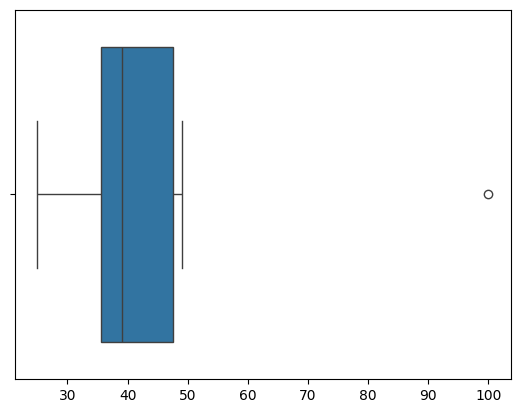

In [ ]:
# we can find outliers using boxplot
import seaborn as sea
sea.boxplot(ages, orient='h')

We will use 5 NUMBER SUMMARY to get
1. Minimum value (Min)
2. 25th percentile (Q1)
3. Median
4. 75th Percentile (Q3)
5. Max Value (Max)

we will also find lower and upper fence with the help of Q1 and Q3.
by first finding IQR (Inter Quartile Range)\

The lower and upper fence is a range, we consider the data as outlier the data is below lower fence or above upper fence.\
An outlier is a data point, person, or thing that differs significantly from the rest of a group, dataset, or pattern.



In [ ]:
## 5 Number Summary

import numpy as np
q1, q3 = np.percentile(ages, [25,75])
# from dataset ages get 25th and 75th percentile as q1, q3

# to check outlier
IQR = q3 - q1 #finding IQR
lower_fence = q1 - 1.5*(IQR)
higher_fence = q3 + 1.5*(IQR)

print(f"[{lower_fence} to {higher_fence}]")

for age in ages:
  if not lower_fence <= age <= higher_fence:
    print(f"{age} is an outlier")


[17.5 to 65.5]
100 is an outlier


## Histogram

A histogram is a graphical representation that organizes numerical data into ranges (bins) to show the frequency distribution of continuous data

<Axes: ylabel='Count'>

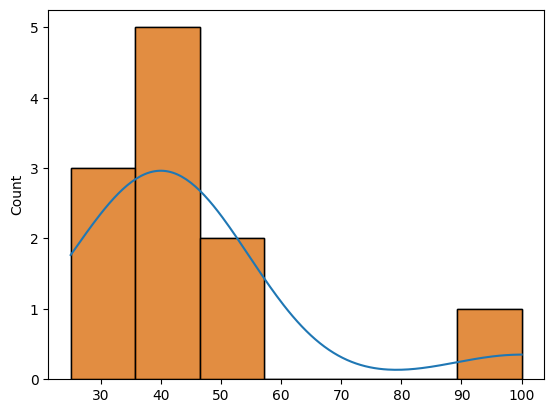

In [12]:
import seaborn as sea
sea.histplot(ages, kde =True) #histogram apko continuos value ka frequency deta h bhai!!
sea.histplot(ages)


Loading the 'iris' dataset from the link and plotting hirograms af different attribute.


In [13]:
from urllib.request import urlretrieve
iris_url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
urlretrieve(iris_url, '/content/iris.csv')

('/content/iris.csv', <http.client.HTTPMessage at 0x7e0c15db2ae0>)

In [14]:
df = sea.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Count'>

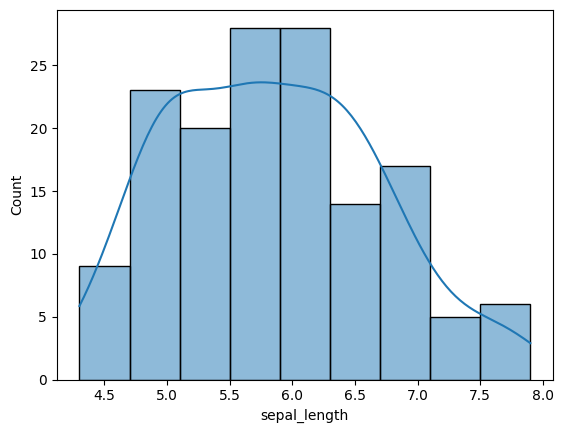

In [15]:
sea.histplot(df['sepal_length'], kde=True)

<Axes: xlabel='sepal_width', ylabel='Count'>

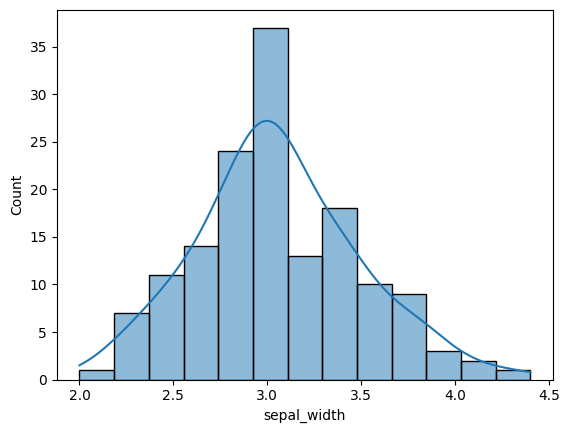

In [16]:
sea.histplot(df['sepal_width'], kde = True) ## Normal Distribution..

<Axes: xlabel='petal_width', ylabel='Count'>

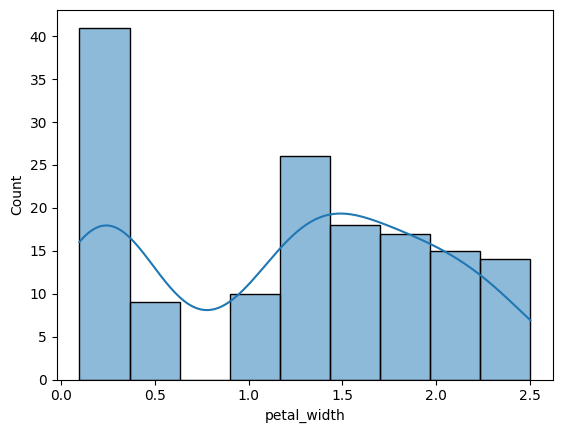

In [17]:
sea.histplot(df['petal_width'],kde = True)

## Probability Distribution Function:
A probability distribution function (PDF) defines the likelihood of different outcomes for a random variable, Mapping values to their probability (discrete) or density (continuous).




## Normal/Guassian DIstribution
forms a bell-shaped curve.

<Axes: ylabel='Count'>

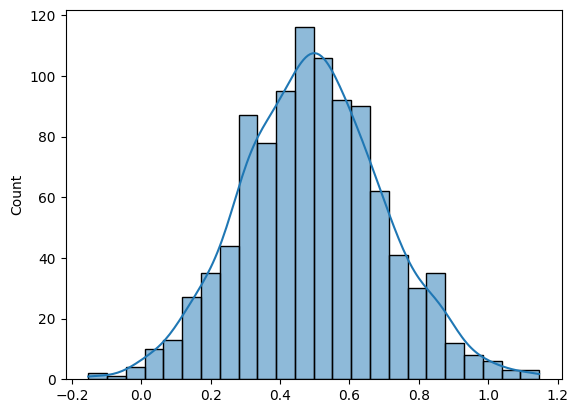

In [18]:
import numpy as np
## create a normal distibuted data
s = np.random.normal(0.5, 0.2, 1000) # .5 = 2, .2 = std, 1000 = datapoints
sea.histplot(s, kde = True
             )

## Log-Normal DIstirbution:
AI Overview
Understanding Log-Normal Distribution: Definition, Uses, and ...A log-normal distribution is a probability distribution of a random variable whose logarithm is normally distributed. It is a right skewed distribution.

<Axes: ylabel='Count'>

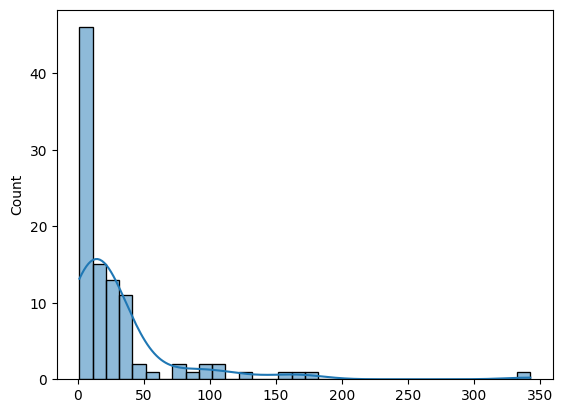

In [19]:
mu, sigma = 3., 1. ## mean and std
s = np.random.lognormal(mu, sigma, 100)
sea.histplot(s, kde=True)

Apply log to this log normal distrubution and it changes to Normal/Guassian Distribution

<Axes: ylabel='Count'>

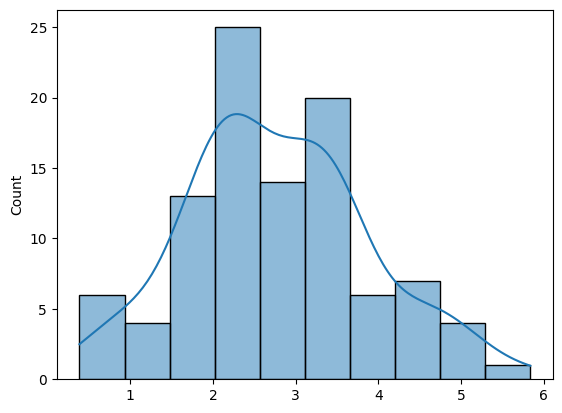

In [20]:
## agar s pe ab log apply kringe toh normal distribution mil jayega apne ko

sea.histplot(np.log(s), kde=True)

Gemini said
📊 Understanding Normality via Q-Q Plots
A Quantile-Quantile (Q-Q) Plot is a graphical method used to determine if a dataset follows a specific distribution, most commonly the Normal (Gaussian) Distribution. Instead of looking at the shape of a curve (like a histogram), you are looking at the relationship between your actual data and a "perfect" theoretical model.

The plot works by calculating the quantiles of your data. A quantile is simply a point that divides your data into equal-sized groups (like percentiles).

The software generates a set of "Expected Quantiles"—where your data points should lie if they were perfectly normal—and plots them against your "Observed Quantiles" (your actual data).

The Reference Line: A straight, 45-degree line is drawn through the plot. This represents a perfect normal distribution.

The Data Points: Your actual data is plotted as individual dots along this line.

In [21]:
# Q-Q Plot
import matplotlib.pyplot as plt
import scipy.stats as stat
import pylab, seaborn as sea

def plot_data(sample):
  plt.figure(figsize = (10,6))
  plt.subplot(1,2,1)
  sea.histplot(sample)
  plt.subplot(1,2,2)
  stat.probplot(sample, dist='norm', plot= pylab)
  plt.show()

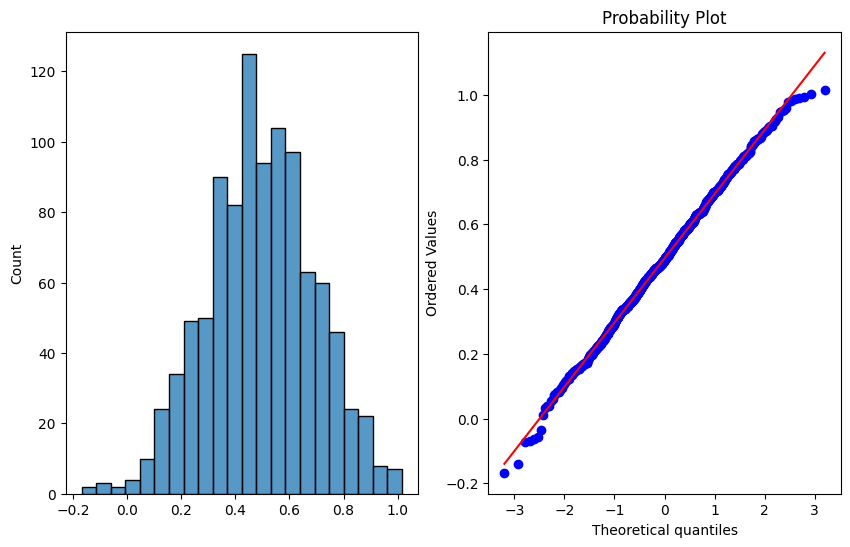

In [22]:
## create a normal distirbuted data
import numpy as np
s = np.random.normal(0.5, 0.2, 1000)
plot_data(s)

Checking log-normal distibution using Q-Q plot

In [23]:
mu , sigma = 3., 1.
sample = np.random.lognormal(mu, sigma, 100)

In [24]:
def plot_data_log(sample):
  plt.figure(figsize = (10, 6))
  plt.subplot(1,2,1)
  sea.histplot(sample)
  plt.subplot(1,2,2)
  stat.probplot(np.log(sample), dist = 'norm', plot = pylab)
  #log for lognormal to normal distibution.
  plt.show()

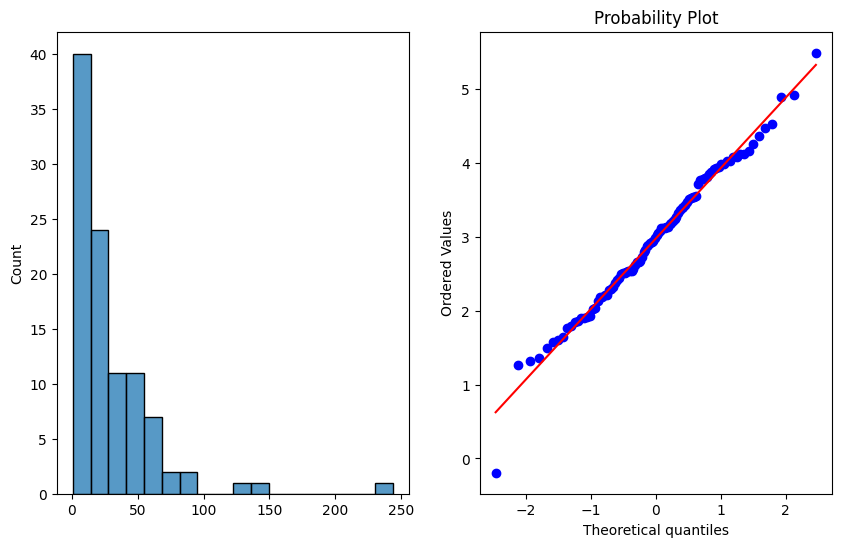

In [25]:
plot_data_log(sample)